<a href="https://colab.research.google.com/github/johnmichaels4867-create/IS4487/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

Choose a City & Upload Your Dataset
📥 Follow these steps:

Go to: https://insideairbnb.com/get-the-data/
Choose a city you’re interested in.
Download the file named: listings.csv.gz under that city.
In your notebook:
Open the left sidebar
Click the folder icon 📁
Click the upload icon ⬆️ and choose your listings.csv.gz file
Use the file path /content/listings.csv.gz when loading your data.
Import standard libraries (pandas, numpy, seaborn, matplotlib)

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data_6.csv` file you exported from Assignment 6. (Note: If you had significant errors with assignment 6, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)

### Do the following:
In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [1]:
# Add code here 🔧

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/cleaned_airbnb_data_6.csv')
display(df.head())

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1534226092176355661,https://www.airbnb.com/rooms/1534226092176355661,20260627230126,2026-06-29,city scrape,Private Suite Oceanfront La Jolla,Private suite in Ocean front Estate in La Jolla,https://a0.muscache.com/pictures/hosting/Hosti...,14064859,https://www.airbnb.com/users/show/14064859,...,NaN,NaN,NaN,No License,NaN,9,6,3,0,NaN
1,1151093362948878244,https://www.airbnb.com/rooms/1151093362948878244,20260627230126,2026-06-29,city scrape,Magical view,Luxury high rise building fully remodeled with...,https://a0.muscache.com/pictures/miso/Hosting-...,365015269,https://www.airbnb.com/users/show/365015269,...,NaN,NaN,NaN,STR-08000L,NaN,1,1,0,0,NaN
2,46566873,https://www.airbnb.com/rooms/46566873,20260627230126,2026-06-28,city scrape,Highland on 60th Large 3BR 4 Beds/2 BA Near SDSU,Centrally located single-family home with a la...,https://a0.muscache.com/pictures/5b341abe-0010...,21897271,https://www.airbnb.com/users/show/21897271,...,4.98,4.91,4.91,"STR-01411L, 644117",NaN,1,1,0,0,3.40
3,683340460312082362,https://www.airbnb.com/rooms/683340460312082362,20260627230126,2026-07-02,previous scrape,"Beautiful, Private Bed & Bath in Central Location",Keep it simple at this peaceful and centrally-...,https://a0.muscache.com/pictures/airflow/Hosti...,21788590,https://www.airbnb.com/users/show/21788590,...,5.00,4.95,5.00,"STR-06725L, 644561",NaN,2,1,1,0,0.45
4,50119879,https://www.airbnb.com/rooms/50119879,20260627230126,2026-06-29,city scrape,Wooden Craftsman Home w/ Private Backyard & Ga...,Make this entire space your new home away from...,https://a0.muscache.com/pictures/8b957cbc-f489...,117810403,https://www.airbnb.com/users/show/117810403,...,4.93,4.98,4.79,"STR-06662L, 648042",NaN,1,1,0,0,0.95


## 2. Check for Skew in a Numeric Column

### Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

### Do the following:
Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare

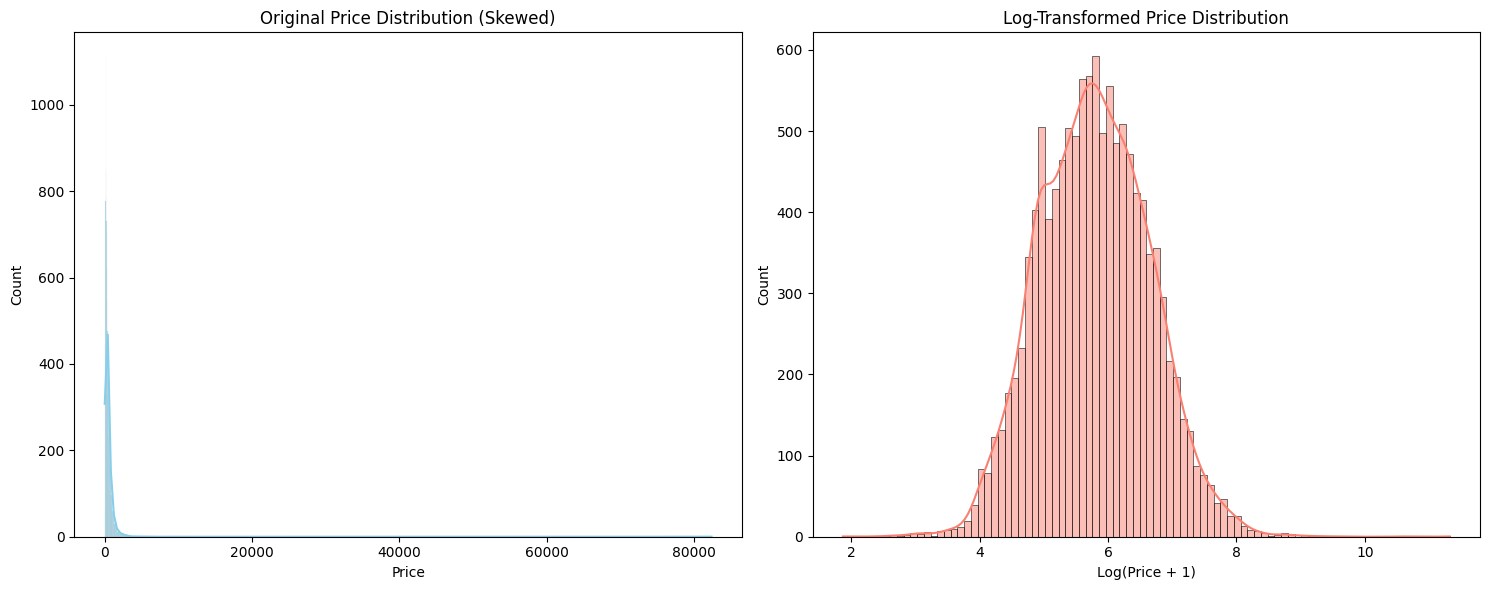

In [2]:
# Add code here 🔧
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Let's check for skew in the 'price' column
original_price = df['price'].dropna()

# Apply log transformation (using log1p to handle any 0 values safely)
log_price = np.log1p(original_price)

# Plot the comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original Price Histogram
sns.histplot(original_price, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Original Price Distribution (Skewed)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

# Log-Transformed Price Histogram
sns.histplot(log_price, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('Log(Price + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Reflection:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?

### ✍️ Your Response: 🔧
1. I examined the price column, which was highly right-skewed due to a few extremely expensive luxury listings and a heavy concentration of budget-friendly listings.

2. I applied a Log transformation (np.log1p) because it reduces the impact of extreme outliers and compresses the wide range of prices, bringing the distribution much closer to a normal/bell-curve distribution.

3. The log-transformed price distribution is much easier to visualize on a standard chart and scales down extreme outliers, making it much more suitable for predictive regression models and enabling stakeholders to clearly see patterns in typical price segments.

## 3. Scale Two Numeric Columns

### Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

### Do the following:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

In [3]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Min-Max scale
min_max_scaler = MinMaxScaler()
df['price_minmax'] = min_max_scaler.fit_transform(df[['price']].fillna(df['price'].median()))

# Z-score scale
standard_scaler = StandardScaler()
df['minimum_nights_zscore'] = standard_scaler.fit_transform(df[['minimum_nights']].fillna(df['minimum_nights'].median()))

# Display scaled results
display(df[['price', 'price_minmax', 'minimum_nights', 'minimum_nights_zscore']].head())

,price,price_minmax,minimum_nights,minimum_nights_zscore
0,NaN,0.003855,31.0,0.906848
1,226.06,0.002679,31.0,0.906848
2,398.58,0.004774,2.0,-0.450225
3,NaN,0.003855,3.0,-0.403430
4,162.57,0.001908,1.0,-0.497021


### Reflection:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

### ✍️ Your Response: 🔧
1. I scaled price using Min-Max scaling (scaling values to a 0-1 range) and minimum_nights using Z-score Normalization/Standardization (scaling values to have a mean of 0 and a standard deviation of 1).

2. These scaled values are more useful than the originals when building machine learning models (such as KNN, SVM, or gradient descent-based algorithms) because they prevent columns with naturally larger absolute values (like price) from dominating columns with smaller ranges (like minimum nights).

3. Data scientists and business analysts at Airbnb benefit from this because standardized inputs lead to faster model training, more accurate clustering of listings, and more reliable predictive insights for pricing recommendations.

## 4. Group a Numeric Column into Categories

### Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

### Do the following:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

In [4]:
# Add code here 🔧

# We will use 'number_of_reviews' to represent review activity
# To handle the distribution evenly or using business logic, we'll use pd.qcut
# for quantile-based bins, or pd.cut with custom bin boundaries.
# Since many listings have 0 or very few reviews, we'll use custom bins:
# 0 to 5 reviews -> Low
# 6 to 30 reviews -> Medium
# More than 30 reviews -> High

bins = [-1, 5, 30, float('inf')]
labels = ['Low', 'Medium', 'High']

df['review_volume'] = pd.cut(df['number_of_reviews'].fillna(0), bins=bins, labels=labels)

# Display some sample values and count distribution
display(df[['number_of_reviews', 'review_volume']].head(10))
print("Value counts for the new column:")
print(df['review_volume'].value_counts())

,number_of_reviews,review_volume
0,0,Low
1,0,Low
2,207,High
3,21,Medium
4,58,High
5,1,Low
6,0,Low
7,0,Low
8,105,High
9,1,Low


Value counts for the new column:
review_volume
High      6064
Low       4250
Medium    2911
Name: count, dtype: int64


### Reflection:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?

### ✍️ Your Response: 🔧
1. I grouped the number_of_reviews column into 3 categories: 'Low', 'Medium', and 'High'.

2. Someone might prefer this grouped view over raw numbers because it simplifies complex numeric data into intuitive categories. Instead of looking at exact count differences, they can quickly grasp the overall tier of activity.

3. This helps the Airbnb Marketing and Customer Success teams. It allows them to segment hosts easily and target low-activity listings with tips on how to get more bookings, or highlight high-activity listings in promotional campaigns.

## 5. Create Two New Business-Relevant Variables

### Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

### Do the following:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

In [5]:
# Add code here 🔧

# 1. Cost per person (Price divided by Accommodates)
# This tells stakeholders the cost relative to the size/capacity of the listing
df['cost_per_person'] = df['price'] / df['accommodates'].replace(0, np.nan)

# 2. Is Long Term Stay (Boolean flag indicating if minimum nights is 30 or more)
df['is_long_term_stay'] = df['minimum_nights'] >= 30

# Display the new variables alongside their source columns
display(df[['price', 'accommodates', 'cost_per_person', 'minimum_nights', 'is_long_term_stay']].head(10))

,price,accommodates,cost_per_person,minimum_nights,is_long_term_stay
0,NaN,1,NaN,31.0,True
1,226.06,4,56.515000,31.0,True
2,398.58,8,49.822500,2.0,False
3,NaN,2,NaN,3.0,False
4,162.57,6,27.095000,1.0,False
5,104.31,2,52.155000,31.0,True
6,NaN,2,NaN,31.0,True
7,NaN,4,NaN,31.0,True
8,517.33,6,86.221667,3.0,False
9,219.61,2,109.805000,31.0,True


### Reflection:
1. What two new columns did you create and why?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

### ✍️ Your Response: 🔧
1. **Columns Created:**
   cost_per_person: Calculated as price divided by the accommodates column (with division by zero protection). This normalizes the listing price by its maximum guest capacity.
   is_long_term_stay: A boolean flag identifying listings with a minimum_nights requirement of 30 days or more.

2. **Target Audience:**
   cost_per_person is highly valuable to **budget-conscious guests** and **hosts** looking to competitively price their property relative to its capacity.
   is_long_term_stay is critical for **Airbnb Platform Managers**, **city planners**, and **policy compliance officers** tracking long-term rental trends and local zoning regulations.

3. **Decision Support:**
   **For Hosts:** Comparing their cost_per_person with nearby listings helps them determine if they are overcharging or undercharging larger groups.
   **For Platform Analysts/Policy Makers:** The is_long_term_stay flag helps segment the platform's inventory to monitor the impact of short-term rental bans or analyze the growth of digital nomad monthly bookings.

## 6. Encode a Categorical Column

### Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

### Do the following:
- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

In [6]:
# Add code here 🔧

# 1. One-hot encode the 'room_type' column
encoded_room_types = pd.get_dummies(df['room_type'], prefix='room_type', dtype=int)

# 2. Concatenate the new one-hot encoded columns back to our DataFrame
df = pd.concat([df, encoded_room_types], axis=1)

# Display the original column alongside the newly created dummy columns
display(df[['room_type'] + list(encoded_room_types.columns)].head(10))

,room_type,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,Private room,0,0,1,0
1,Entire home/apt,1,0,0,0
2,Entire home/apt,1,0,0,0
3,Private room,0,0,1,0
4,Entire home/apt,1,0,0,0
5,Entire home/apt,1,0,0,0
6,Private room,0,0,1,0
7,Entire home/apt,1,0,0,0
8,Entire home/apt,1,0,0,0
9,Entire home/apt,1,0,0,0


### Reflection:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?

### ✍️ Your Response: 🔧
1. **Column Encoded and Why:**
   I encoded the room_type column. This categorical column provides critical details about the style of accommodation. Converting this text field into numerical columns is necessary because machine learning models require numeric inputs to compute mathematical relationships.

2. **Encoding Method:**
   I used **One-Hot Encoding**. This method was selected because the categories in room_type are nominal, meaning they have no natural, mathematical ranking or logical order.

3. **Business & Technical Value:**
   **For Pricing Models:** Regression algorithms can now assign an exact numerical weight (coefficient) to each specific room type, making it possible to quantify precisely how much premium an entire home commands compared to a shared room.
   **For Dashboards and Business Reports:** Analysts can use these binary columns to easily build aggregated metrics without relying on slower, string based grouping commands.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 11**, where you'll use the data in a regression model.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_7.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

In [9]:
# export csv here 🔧
df.to_csv('cleaned_airbnb_data_7.csv', index=False)


## 8. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### Reflection:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. **Most Important/Interesting Step:**
   The categorical encoding of the room_type column was the most interesting step. Converting unstructured text classifications into structured, machine-readable binary columns (one-hot encoding) directly bridges the gap between qualitative characteristics and quantitative modeling.

2. **Most Useful Changes for Stakeholders:**
   **For Hosts:** The newly created cost_per_person metric is highly useful as it allows them to benchmark pricing based directly on property capacity rather than flat rates.
   **For City Planners:** The is_long_term_stay column simplifies compliance audits and reveals localized patterns of monthly-stay listings.

3. **Next Steps for a Tool or Dashboard:**
   If building a dashboard, the next step would be to map the spatial distribution of the cost_per_person metric across neighborhood groups to visually identify high value price corridors.

4. **Relation to Learning Outcomes:**
   This mapping exercise directly addresses hands on feature engineering and raw data transformation techniques, improving overall analytical workflows and predictive pipeline pre processing skills.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_07_data_transformation.ipynb"